# 01 EDA & Feature Engineering: College Football Attendance


## Import libraries and the datasets

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

RAW_DATA_DIR = Path("../data/raw")

games_df = pd.read_csv(RAW_DATA_DIR / "cfbd_games_2023_2025.csv")
fbs_stadiums_df = pd.read_csv(RAW_DATA_DIR / "fbs-stadiums-original.csv")
fcs_stadiums_df = pd.read_csv(RAW_DATA_DIR / "fcs-stadiums-original.csv")
geocoded_stad_df = pd.read_csv(RAW_DATA_DIR / "stadiums-geocoded.csv")

### Make sure that datasets are loaded

In [2]:
games_df.head()

,id,season,week,seasonType,startDate,startTimeTBD,completed,neutralSite,conferenceGame,attendance,...,awayConference,awayPoints,awayLineScores,awayPostgameWinProbability,awayPregameElo,awayPostgameElo,excitementIndex,highlights,notes,playoff
0,401525434,2023,1,regular,2023-08-26T18:30:00.000Z,False,True,True,False,49000.0,...,American Athletic,3.0,"[0, 0, 0, 3]",0.023594,1471.0,1385.0,1.646466,NaN,NaN,NaN
1,401540199,2023,1,regular,2023-08-26T19:30:00.000Z,False,True,True,False,NaN,...,UAC,7.0,"[7, 0, 0, 0]",0.031442,NaN,NaN,4.165937,NaN,NaN,NaN
2,401520145,2023,1,regular,2023-08-26T21:30:00.000Z,False,True,False,True,17982.0,...,Conference USA,14.0,"[0, 7, 0, 7]",0.192517,1369.0,1370.0,4.604490,NaN,NaN,NaN
3,401525450,2023,1,regular,2023-08-26T23:00:00.000Z,False,True,False,False,15356.0,...,FBS Independents,41.0,"[7, 3, 3, 28]",0.882491,1074.0,1122.0,5.430058,NaN,NaN,NaN
4,401532392,2023,1,regular,2023-08-26T23:00:00.000Z,False,True,False,False,23867.0,...,Mid-American,13.0,"[3, 3, 0, 7]",0.121683,1482.0,1473.0,5.105937,NaN,NaN,NaN


In [3]:
fbs_stadiums_df.head()

,image,stadium,city,state,team,conference,capacity,built,expanded
0,Michigan Stadium 2011.jpg,Michigan Stadium,Ann Arbor,MI,Michigan,Big Ten,"107,601[98]",1927,2015
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Beaver Stadium inside.jpg,Beaver Stadium,University Park,PA,Penn State,Big Ten,"106,572[12]",1960,2001
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Ohio Stadium, Columbus.jpg",Ohio Stadium,Columbus,OH,Ohio State,Big Ten,"104,944[106]",1922[108],2014[108]


In [4]:
fcs_stadiums_df.head()

,image,stadium,city,state,team,conference,capacity,built,expanded
0,LP Field 2009 crop.jpg,LP Field,Nashville,Tennessee,Tennessee State Tigers,Ohio Valley,"68,798",1999,NaN
1,Yale bowl birds eye view.png,Yale Bowl,New Haven,Connecticut,Yale Bulldogs,Ivy,"61,446[106]",1914[106],NaN
2,Mississippi Veterans Memorial Stadium.jpg,Mississippi Veterans Memorial Stadium,Jackson,Mississippi,Jackson State Tigers,SWAC,"60,492",1941[69],NaN
3,Franklin Field aerial.jpg,Franklin Field,Philadelphia,Pennsylvania,Penn Quakers,Ivy,"52,593[37]",1895[37],NaN
4,Harvard Stadium aerial.jpg,Harvard Stadium,Boston,Massachusetts,Harvard Crimson,Ivy,"30,323[48]",1903[48],2007[48]


In [5]:
geocoded_stad_df.head()

,stadium,city,state,team,conference,capacity,built,expanded,div,latitude,longitude
0,Michigan Stadium,Ann Arbor,MI,Michigan,Big Ten,107601,1927,2015,fbs,42.265869,-83.748726
1,Beaver Stadium,University Park,PA,Penn State,Big Ten,106572,1960,2001,fbs,40.812153,-77.856202
2,Ohio Stadium,Columbus,OH,Ohio State,Big Ten,104944,1922,2014,fbs,40.001686,-83.019728
3,Kyle Field,College Station,TX,Texas A&M,SEC,102733,1927,2015,fbs,30.610098,-96.340729
4,Neyland Stadium,Knoxville,TN,Tennessee,SEC,102455,1921,2010,fbs,35.954734,-83.925333


# Exploratory Data Analysis (EDA)

## 1. Loading the Raw Data
Raw 2023 college football game data exported during the data collection stage is loaded directly from the `data/raw` folder. The data is kept unchanged at this stage so its original structure and quality can be examined before any cleaning or feature engineering.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the raw data exported during data collection
raw_df = pd.read_csv("../data/raw/cfbd_games_2023.csv")

raw_df.head()

,id,season,week,seasonType,startDate,startTimeTBD,completed,neutralSite,conferenceGame,attendance,...,awayConference,awayPoints,awayLineScores,awayPostgameWinProbability,awayPregameElo,awayPostgameElo,excitementIndex,highlights,notes,playoff
0,401525434,2023,1,regular,2023-08-26T18:30:00.000Z,False,True,True,False,49000.0,...,American Athletic,3.0,"[0, 0, 0, 3]",0.001042,1471.0,1385.0,1.346908,NaN,NaN,NaN
1,401540199,2023,1,regular,2023-08-26T19:30:00.000Z,False,True,True,False,NaN,...,UAC,7.0,"[7, 0, 0, 0]",0.025849,NaN,NaN,6.896909,NaN,NaN,NaN
2,401520145,2023,1,regular,2023-08-26T21:30:00.000Z,False,True,False,True,17982.0,...,Conference USA,14.0,"[0, 7, 0, 7]",0.591999,1369.0,1370.0,6.821333,NaN,NaN,NaN
3,401525450,2023,1,regular,2023-08-26T23:00:00.000Z,False,True,False,False,15356.0,...,FBS Independents,41.0,"[7, 3, 3, 28]",0.760751,1074.0,1122.0,5.311493,NaN,NaN,NaN
4,401540628,2023,1,regular,2023-08-26T23:00:00.000Z,False,True,False,False,NaN,...,Patriot,13.0,"[3, 3, 7, 0]",0.077483,NaN,NaN,5.608758,NaN,NaN,NaN


## 2. Dataset Structure and Content

Examining the overall structure of the raw dataset to understand its size, type, and info available per game.

In [19]:
# Examine the size and structure of the dataset
print("Number of rows:", raw_df.shape[0])
print("Number of columns:", raw_df.shape[1])

# Display each column and its data type
raw_df.dtypes

Number of rows: 3595
Number of columns: 34


id                              int64
season                          int64
week                            int64
seasonType                     object
startDate                      object
startTimeTBD                     bool
completed                        bool
neutralSite                      bool
conferenceGame                   bool
attendance                    float64
venueId                       float64
venue                          object
homeId                          int64
homeTeam                       object
homeClassification             object
homeConference                 object
homePoints                    float64
homeLineScores                 object
homePostgameWinProbability    float64
homePregameElo                float64
homePostgameElo               float64
awayId                          int64
awayTeam                       object
awayClassification             object
awayConference                 object
awayPoints                    float64
awayLineScor

### Column Content

The dataset contains variables describing game timing and status, venue information, attendance, home and away teams, scoring, team strength metrics, and additional game metadata. Examining these groups helps identify which variables may be useful for analyzing turnout and which may require additional investigation.

In [20]:
# Display all column names
for column in raw_df.columns:
    print(column)

id
season
week
seasonType
startDate
startTimeTBD
completed
neutralSite
conferenceGame
attendance
venueId
venue
homeId
homeTeam
homeClassification
homeConference
homePoints
homeLineScores
homePostgameWinProbability
homePregameElo
homePostgameElo
awayId
awayTeam
awayClassification
awayConference
awayPoints
awayLineScores
awayPostgameWinProbability
awayPregameElo
awayPostgameElo
excitementIndex
highlights
notes
playoff


## 3. Missing Data and Completeness

Missing values are examined to determine how complete each variable is and to identify fields that may create issues during later analysis and modeling. Both the number and percentage of missing values are considered cause some variables may have limited coverage across the dataset.

In [21]:
# Calculate the number and percentage of missing values in each column
missing_data = pd.DataFrame({
    "Missing Count": raw_df.isnull().sum(),
    "Missing Percentage": (raw_df.isnull().sum() / len(raw_df) * 100).round(2)
})

# Only display columns that contain missing values
missing_data = missing_data[missing_data["Missing Count"] > 0]

# Sort from highest to lowest percentage missing
missing_data = missing_data.sort_values("Missing Percentage", ascending=False)

missing_data

,Missing Count,Missing Percentage
playoff,3595,100.00
highlights,3595,100.00
notes,3577,99.50
awayPregameElo,2845,79.14
awayPostgameElo,2845,79.14
attendance,2744,76.33
homePregameElo,2727,75.86
homePostgameElo,2727,75.86
homePostgameWinProbability,2142,59.58
awayPostgameWinProbability,2142,59.58


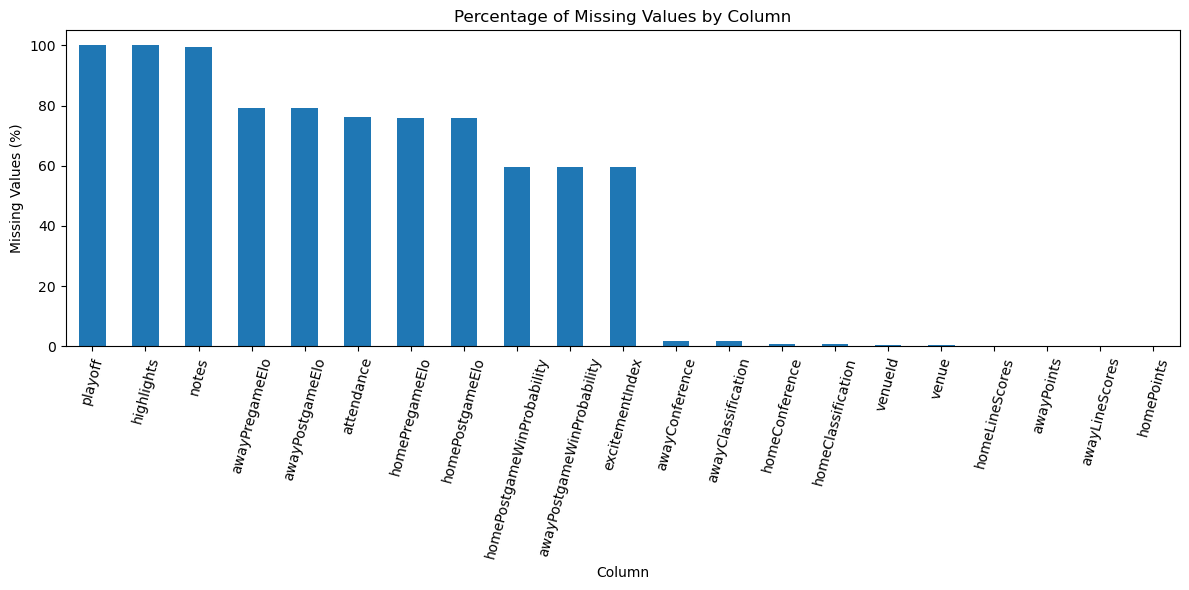

In [22]:
# Visualize missing data percentages
missing_data["Missing Percentage"].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Percentage of Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

### Missing Data Findings

- The dataset contains several variables with substantial amounts of missing data. `playoff` and `highlights` are completely missing, while `notes` is missing for 99.5% of games. The pregame and postgame Elo variables are also missing for roughly 76–79% of observations, and the postgame win probability and excitement index variables are missing for about 59% of games
- Most importantly for this project, `attendance` is missing for 2,744 of the 3,595 games (76.33%). This leaves only 851 games with reported attendance values. Because attendance will be important for eventually defining the turnout target, this limited coverage will need to be considered before modeling
- Other variables, including venue, team classification, conference, and scoring information, have relatively little missing data compared with these higher-missingness variables

## 4. Data Quality and Consistency

Raw data is checked for duplicate games and potentially inconsistent or unusual values. These checks help identify issues that could affect later analysis or modeling.

In [23]:
# Check for duplicate rows and duplicate game IDs
print("Duplicate rows:", raw_df.duplicated().sum())
print("Duplicate game IDs:", raw_df["id"].duplicated().sum())

# Check important game status variables
print("\nCompleted games:")
print(raw_df["completed"].value_counts(dropna=False))

print("\nNeutral-site games:")
print(raw_df["neutralSite"].value_counts(dropna=False))

print("\nSeason types:")
print(raw_df["seasonType"].value_counts(dropna=False))

Duplicate rows: 0
Duplicate game IDs: 0

Completed games:
completed
True     3585
False      10
Name: count, dtype: int64

Neutral-site games:
neutralSite
False    3490
True      105
Name: count, dtype: int64

Season types:
seasonType
regular    3595
Name: count, dtype: int64


In [24]:
# Examine team classifications and conference information
print("Home team classifications:")
print(raw_df["homeClassification"].value_counts(dropna=False))

print("\nAway team classifications:")
print(raw_df["awayClassification"].value_counts(dropna=False))

print("\nNumber of unique home teams:", raw_df["homeTeam"].nunique())
print("Number of unique venues:", raw_df["venue"].nunique())

Home team classifications:
homeClassification
iii    1176
fbs     868
ii      864
fcs     666
NaN      21
Name: count, dtype: int64

Away team classifications:
awayClassification
iii    1178
ii      876
fbs     750
fcs     730
NaN      61
Name: count, dtype: int64

Number of unique home teams: 680
Number of unique venues: 696


In [25]:
# Check attendance availability by home team classification
attendance_by_classification = raw_df.groupby(
    "homeClassification",
    dropna=False
)["attendance"].agg(
    Total_Games="size",
    Games_With_Attendance="count"
)

attendance_by_classification["Attendance_Coverage_Percentage"] = (
    attendance_by_classification["Games_With_Attendance"]
    / attendance_by_classification["Total_Games"] * 100
).round(2)

attendance_by_classification

,Total_Games,Games_With_Attendance,Attendance_Coverage_Percentage
homeClassification,,,
fbs,868,851,98.04
fcs,666,0,0.00
ii,864,0,0.00
iii,1176,0,0.00
NaN,21,0,0.00


In [26]:
# Check the range of reported attendance values
print("Minimum reported attendance:", raw_df["attendance"].min())
print("Maximum reported attendance:", raw_df["attendance"].max())
print("Zero attendance values:", (raw_df["attendance"] == 0).sum())
print("Negative attendance values:", (raw_df["attendance"] < 0).sum())

# Examine FBS games where attendance is missing
fbs_missing_attendance = raw_df[
    (raw_df["homeClassification"] == "fbs") &
    (raw_df["attendance"].isna())
]

print("\nFBS games with missing attendance:", len(fbs_missing_attendance))

fbs_missing_attendance[
    ["week", "homeTeam", "awayTeam", "venue", "completed", "neutralSite"]
]

Minimum reported attendance: 5349.0
Maximum reported attendance: 110856.0
Zero attendance values: 0
Negative attendance values: 0

FBS games with missing attendance: 17


,week,homeTeam,awayTeam,venue,completed,neutralSite
96,1,Michigan State,Central Michigan,Spartan Stadium,True,False
99,1,Georgia Tech,Louisville,Mercedes-Benz Stadium,True,True
498,2,Michigan State,Richmond,Spartan Stadium,True,False
694,3,Indiana,Louisville,Lucas Oil Stadium,True,True
1599,6,Texas,Oklahoma,Cotton Bowl,True,True
2088,7,South Florida,Florida Atlantic,Raymond James Stadium,True,False
2128,7,Georgia State,Marshall,Center Parc Stadium,True,False
2184,8,Indiana,Rutgers,"Memorial Stadium (Bloomington, IN)",True,False
2461,8,Stanford,UCLA,Stanford Stadium,True,False
3022,10,Northwestern,Iowa,Wrigley Field,True,True


### Data Quality Findings

- No duplicate rows or duplicate game IDs were found, suggesting that each game is represented only once in the dataset
- Nearly all games are marked as completed (3,585 of 3,595), and all records are regular-season games
- There are  105 neutral-site games, which may need special consideration because the project focuses on home-game stadium attendance
- The dataset includes multiple levels of college football, including FBS, FCS, Division II, and Division III
- Attendance availability is strongly associated with home-team classification. Of the 868 games with an FBS home team, 851 (98.04%) have reported attendance
- None of the FCS, Division II, or Division III home games have reported attendance 
- The overall 76.33% missing rate for attendance is largely explained by the inclusion of non-FBS games rather than missing attendance being evenly distributed throughout the dataset
- Among reported attendance values, no zero or negative values were found, and attendance ranges from 5,349 to 110,856 
- There are 17 FBS games with missing attendance, including both neutral-site and non-neutral-site games, so neutral-site status alone does not explain the remaining missing FBS attendance values

## 5. Attendance and Turnout Analysis

Because attendance is the raw variable most closely related to turnout, the available attendance values are examined in more detail. This analysis focuses on the distribution and variation in reported attendance across games to better understand how turnout may eventually be represented in the model.

In [27]:
# Summary statistics for games with reported attendance
attendance_data = raw_df["attendance"].dropna()

attendance_data.describe()

count       851.000000
mean      42216.165687
std       26578.537242
min        5349.000000
25%       20033.000000
50%       36447.000000
75%       58694.500000
max      110856.000000
Name: attendance, dtype: float64

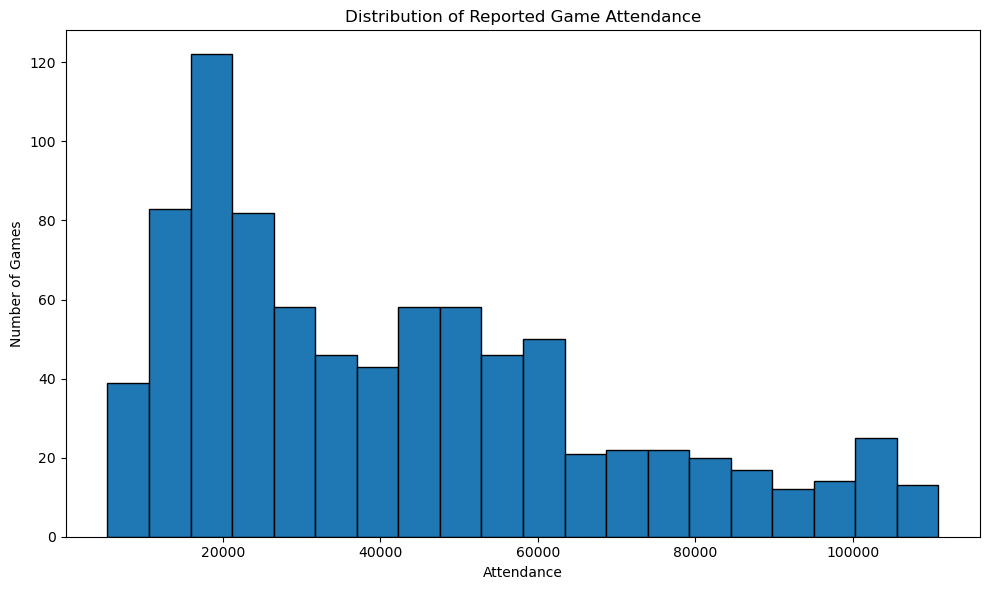

In [28]:
# Visualize the distribution of reported attendance
plt.figure(figsize=(10, 6))

plt.hist(attendance_data, bins=20, edgecolor="black")

plt.title("Distribution of Reported Game Attendance")
plt.xlabel("Attendance")
plt.ylabel("Number of Games")

plt.tight_layout()
plt.show()

### Attendance Distribution Findings

- Reported attendance varies substantially across games, ranging from 5,349 to 110,856 attendees
- The median attendance is 36,447, while the mean is higher at approximately 42,216, indicating that higher-attendance games pull the average upward
- The histogram also shows a longer upper tail, with a smaller number of games drawing crowds above 80,000–100,000

This variation shows that raw attendance alone may not fully represent how strong turnout was for a game, since stadiums can differ greatly in capacity.

In [29]:
# Calculate attendance statistics by week
attendance_by_week = raw_df.groupby("week")["attendance"].agg(
    Games_With_Attendance="count",
    Average_Attendance="mean",
    Median_Attendance="median"
).round(0)

attendance_by_week

,Games_With_Attendance,Average_Attendance,Median_Attendance
week,,,
1,92,42540.0,37552.0
2,84,42910.0,39166.0
3,74,44666.0,40122.0
4,67,43932.0,38046.0
5,59,39144.0,30364.0
6,50,42048.0,36464.0
7,53,42315.0,34252.0
8,52,40370.0,30928.0
9,54,41629.0,36424.0


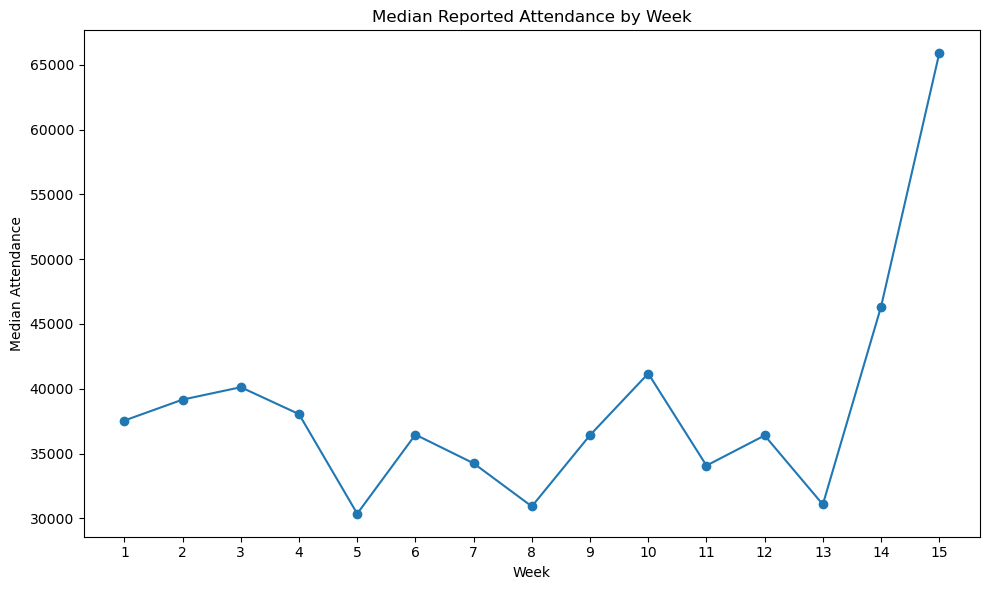

In [30]:
# Visualize median reported attendance by week
weekly_median = raw_df.groupby("week")["attendance"].median()

plt.figure(figsize=(10, 6))
plt.plot(weekly_median.index, weekly_median.values, marker="o")

plt.title("Median Reported Attendance by Week")
plt.xlabel("Week")
plt.ylabel("Median Attendance")
plt.xticks(weekly_median.index)

plt.tight_layout()
plt.show()

### Attendance by Week

- For most of the regular season, reported attendance does not show a strong consistent upward or downward trend by week
- From weeks 1–13, average attendance remains relatively stable, generally between about 39,000 and 45,000 attendees, although median attendance varies more across weeks
- Weeks 14 and 15 have far fewer games with reported attendance, with only 10 and 1 respectively, so their higher attendance values should not be interpreted as a general late-season trend

In [31]:
# Compare reported attendance across home conferences
conference_attendance = (
    raw_df.dropna(subset=["attendance"])
    .groupby("homeConference")["attendance"]
    .agg(
        Games_With_Attendance="count",
        Average_Attendance="mean",
        Median_Attendance="median"
    )
    .round(0)
    .sort_values("Median_Attendance", ascending=False)
)

conference_attendance

,Games_With_Attendance,Average_Attendance,Median_Attendance
homeConference,,,
SEC,101,76748.0,78311.0
Big Ten,92,67312.0,62288.0
Pac-12,79,48987.0,51532.0
Big 12,93,54725.0,51481.0
ACC,94,49342.0,48419.0
FBS Independents,26,37163.0,28431.0
Mountain West,76,23966.0,22576.0
American Athletic,86,23743.0,21652.0
Sun Belt,84,20886.0,19512.0


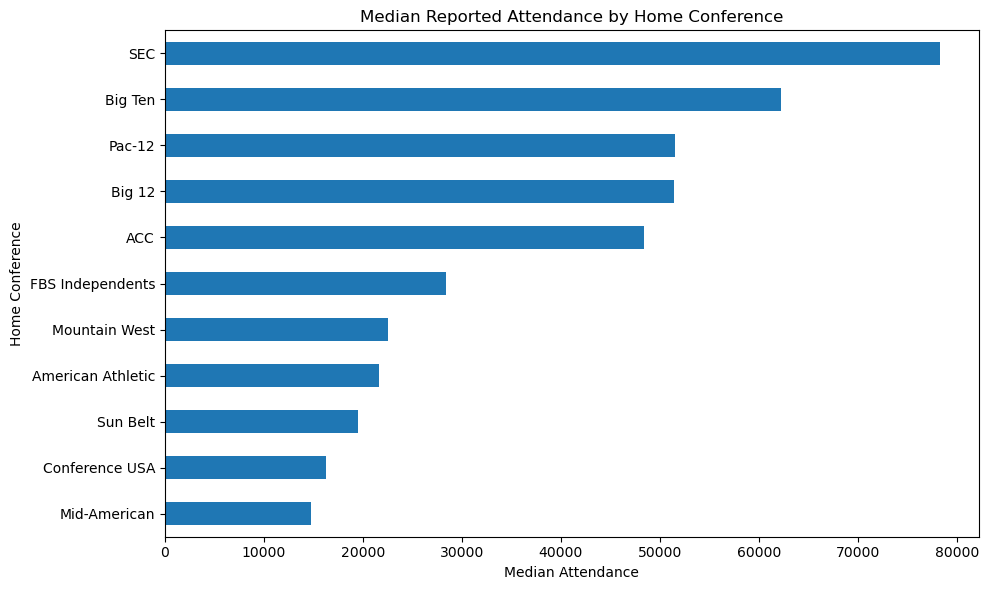

In [32]:
# Visualize median reported attendance by home conference
plt.figure(figsize=(10, 6))

conference_attendance["Median_Attendance"].sort_values().plot(
    kind="barh"
)

plt.title("Median Reported Attendance by Home Conference")
plt.xlabel("Median Attendance")
plt.ylabel("Home Conference")

plt.tight_layout()
plt.show()

### Attendance by Home Conference Findings

- Reported attendance differs substantially across home conferences
- The SEC has the highest median attendance at approximately 78,311 attendees, followed by the Big Ten at approximately 62,288
- In comparison, several conferences have median attendance below 25,000, with the Mid-American Conference having the lowest median at approximately 14,736
- These differences suggest that typical crowd size varies considerably across teams and conferences. As a result, using the same raw attendance threshold to define "high turnout" for every game could be misleading. A crowd that is relatively large for one team's stadium may be relatively small for another.

## 6. Considerations for Defining Turnout

In [33]:
# Check for columns related to stadium capacity
capacity_columns = [
    column for column in raw_df.columns
    if "capacity" in column.lower()
]

print("Capacity-related columns:", capacity_columns)

Capacity-related columns: []


### Turnout Target Considerations

- The raw game dataset does not contain a stadium capacity variable. Although attendance is available for most FBS home games, raw attendance alone may not accurately represent turnout because stadiums vary substantially in size.
- For example, the analysis by home conference showed large differences in typical reported attendance across conferences. Therefore, a single raw attendance threshold could classify games unfairly across teams with different stadium sizes.
- To eventually define turnout relative to capacity, stadium capacity information will need to be obtained and matched to the game data, potentially using the existing `venue` or `venueId` variables. A measure such as attendance divided by stadium capacity could then provide a more comparable measure of turnout across games.

## 7. Key EDA Findings

- The raw 2023 dataset contains 3,595 games and 34 variables covering game information, teams, venues, scores, rankings, and attendance.
- No duplicate rows or duplicate game IDs were identified.
- The dataset contains games from FBS, FCS, Division II, and Division III, rather than only FBS games.
- Attendance initially appears highly incomplete, with 76.33% of values missing. However, the missingness is strongly associated with classification: 851 of 868 FBS home games (98.04%) report attendance, while no attendance values are reported for FCS, Division II, or Division III home games.
- Among reported attendance values, no zero or negative values were identified. Attendance ranges from 5,349 to 110,856, with a median of 36,447 and mean of approximately 42,216.
- Attendance varies considerably across games and home conferences. The distribution has a longer upper tail, with some games drawing crowds above 80,000–100,000.
- Attendance does not show a clear consistent trend across weeks 1–13. Weeks 14 and 15 have much smaller sample sizes, so their higher median values should be interpreted cautiously.
- The raw dataset does not contain stadium capacity. Because the project's turnout target will need to account for stadium size, additional capacity information will eventually need to be matched to the game data before a relative turnout measure can be defined.